In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/coffee-sales/Coffee Data.csv


## **Library 1**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
from sklearn.pipeline import Pipeline

## **1.Dataset Loading**

In [3]:
df=pd.read_csv('/kaggle/input/coffee-sales/Coffee Data.csv')

In [4]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


In [6]:
df=df.drop(columns=['date','cash_type','card'])

In [7]:
df.head()

,datetime,money,coffee_name
0,2024-03-01 10:15:50.520,38.7,Latte
1,2024-03-01 12:19:22.539,38.7,Hot Chocolate
2,2024-03-01 12:20:18.089,38.7,Hot Chocolate
3,2024-03-01 13:46:33.006,28.9,Americano
4,2024-03-01 13:48:14.626,38.7,Latte


## **2. EDA**

<Axes: ylabel='coffee_name'>

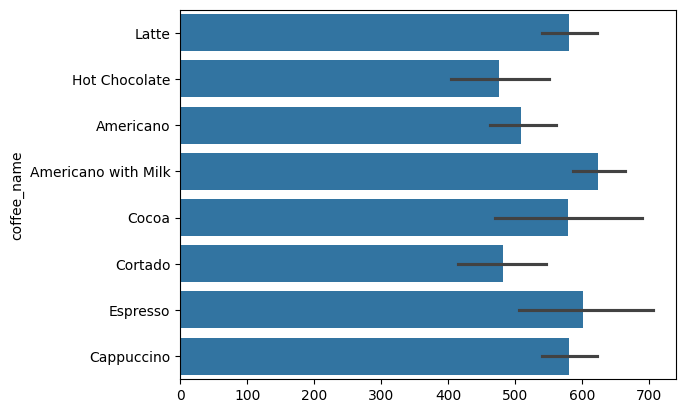

In [8]:
sns.barplot(df['coffee_name'])

In [9]:
df['coffee_name'].value_counts()

coffee_name
Americano with Milk    268
Latte                  243
Cappuccino             196
Americano              169
Cortado                 99
Hot Chocolate           74
Espresso                49
Cocoa                   35
Name: count, dtype: int64

In [10]:
df.isnull().sum()

datetime       0
money          0
coffee_name    0
dtype: int64

In [11]:
X=df.drop(columns=['money'])
y=df['money']

In [12]:
X.head()

,datetime,coffee_name
0,2024-03-01 10:15:50.520,Latte
1,2024-03-01 12:19:22.539,Hot Chocolate
2,2024-03-01 12:20:18.089,Hot Chocolate
3,2024-03-01 13:46:33.006,Americano
4,2024-03-01 13:48:14.626,Latte


In [13]:
X['datetime']=pd.to_datetime(X['datetime'])

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     1133 non-null   datetime64[ns]
 1   coffee_name  1133 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 17.8+ KB


## Extracting hour,day of week,month

In [15]:
X['hour']=X['datetime'].dt.hour
X['month']=X['datetime'].dt.month
X['dayofweek']=X['datetime'].dt.dayofweek

In [16]:
X=X.drop(columns=['datetime'])

In [17]:
X.head()

,coffee_name,hour,month,dayofweek
0,Latte,10,3,4
1,Hot Chocolate,12,3,4
2,Hot Chocolate,12,3,4
3,Americano,13,3,4
4,Latte,13,3,4


In [18]:
X=pd.get_dummies(X,columns=['coffee_name'],drop_first=True)

In [19]:
X=X.astype(int)
X.head()

,hour,month,dayofweek,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte
0,10,3,4,0,0,0,0,0,0,1
1,12,3,4,0,0,0,0,0,1,0
2,12,3,4,0,0,0,0,0,1,0
3,13,3,4,0,0,0,0,0,0,0
4,13,3,4,0,0,0,0,0,0,1


In [20]:
y.head()

0    38.7
1    38.7
2    38.7
3    28.9
4    38.7
Name: money, dtype: float64

## **3.Train test split**

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=43)

In [22]:
X_train.shape

(793, 10)

In [23]:
X_test.shape

(340, 10)

In [24]:
y_train.shape

(793,)

## **Library 2**

## Prediction is for Regression Parameter

In [25]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.pipeline import Pipeline

models={'Linear Regression':LinearRegression(),
        'Lasso':Lasso(),
        'Ridge':Ridge(),
        'ElasticNet':ElasticNet(),
        'Decision Trees Regression':DecisionTreeRegressor(),
        'Support Vector Machines Regression':SVR(),
        'K Neighbors Regressor':KNeighborsRegressor(),
        'Random Forest Regressor':RandomForestRegressor(),
        'Gradient Boosting Regressor':GradientBoostingRegressor()

}

In [26]:

results=[]
for model_name,model in models.items():
    print(f' Model name is:{model_name} ')
    
    pipeline=Pipeline([
        ('scaling',StandardScaler()),
        ('model names',model)
        ])
    
    pipeline.fit(X_train,y_train)

    y_pred=pipeline.predict(X_test)
    r2=r2_score(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    results.append({'Model':model_name,
                   'R2 Score':r2,
                   'Mean Squared Error':mse
                    })
    

 Model name is:Linear Regression 
 Model name is:Lasso 
 Model name is:Ridge 
 Model name is:ElasticNet 
 Model name is:Decision Trees Regression 
 Model name is:Support Vector Machines Regression 
 Model name is:K Neighbors Regressor 
 Model name is:Random Forest Regressor 
 Model name is:Gradient Boosting Regressor 


In [27]:
results_df=pd.DataFrame(results).sort_values(by='R2 Score',ascending=False)

## **4. Model Results**

In [28]:
results_df

,Model,R2 Score,Mean Squared Error
7,Random Forest Regressor,0.964025,0.920032
8,Gradient Boosting Regressor,0.960023,1.022386
4,Decision Trees Regression,0.948434,1.318767
6,K Neighbors Regressor,0.930581,1.775341
0,Linear Regression,0.922344,1.986009
2,Ridge,0.922291,1.987359
5,Support Vector Machines Regression,0.910761,2.282223
3,ElasticNet,0.581048,10.714429
1,Lasso,0.526917,12.098788


## **Results Conclusion**
Lower MSE = better

R² closer to 1 = better

## **5. Regression Plot**

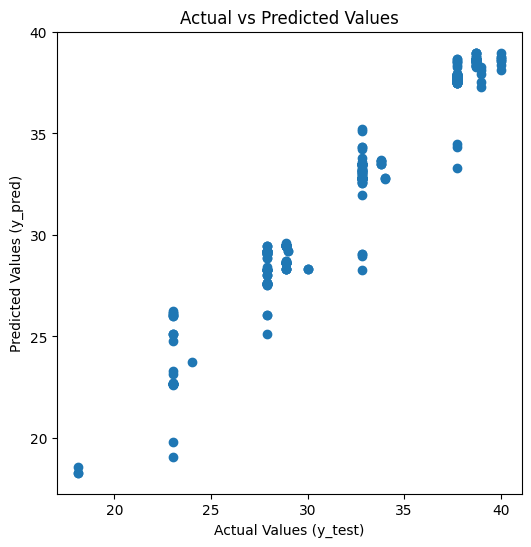

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs Predicted Values")


plt.show()


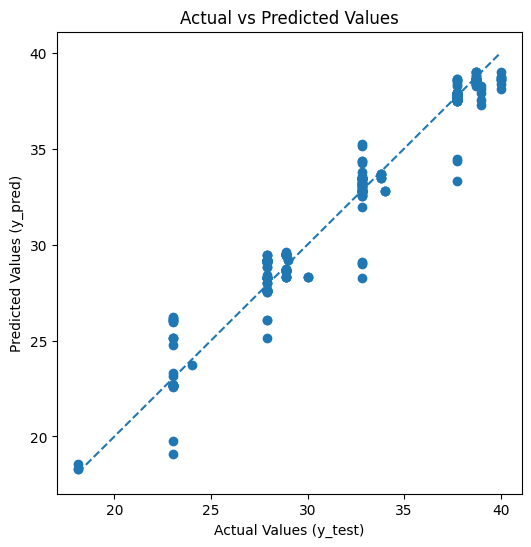

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred)
 
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs Predicted Values")


plt.show()


## **6. Hyper Parameter Tuning**

In [31]:
params_grids={
     'Linear Regression':(
         LinearRegression(),
         {}
          ),
    'Lasso':(
         Lasso(max_iter=500),
         {'model__alpha':[0.001,0.01,0.1,1,10]}
            ),
    'Ridge':(
         Ridge(max_iter=500),
         {'model__alpha':[0.001,0.01,0.1,1,10,50,100]}
            ),
    'Elastic Net':(
        ElasticNet(max_iter=500),
        {'model__alpha':[0.001,0.01,0.1,1,10],
        'model__l1_ratio': [0.2,0.3,0.4,0.6,0.8]}
        ),
    'Decision Trees Regressor ':(
        DecisionTreeRegressor(random_state=43),
        {'model__criterion':['squared_error','friedman_mse', 'absolute_error'],
         'model__splitter':['best','random'],
         "model__max_depth": [None, 5, 10],
         "model__min_samples_split": [2, 5, 10]
        }
    ),
    'KNN Regressor':(
        KNeighborsRegressor(),
        {'model__n_neighbors':[3,5,7],
         'model__weights':['uniform', 'distance']  
        }
        
    ),
    'SVR':(
        SVR(),
        {'model__kernel':['linear', 'poly', 'rbf', 'sigmoid']
        }
    ),
    'Random Forest Estimators':(
        RandomForestRegressor(),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5]
        }
        
    )
    
}


## **Hyper Parameter tuning of all models**

In [32]:
params_grids.items()

dict_items([('Linear Regression', (LinearRegression(), {})), ('Lasso', (Lasso(max_iter=500), {'model__alpha': [0.001, 0.01, 0.1, 1, 10]})), ('Ridge', (Ridge(max_iter=500), {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]})), ('Elastic Net', (ElasticNet(max_iter=500), {'model__alpha': [0.001, 0.01, 0.1, 1, 10], 'model__l1_ratio': [0.2, 0.3, 0.4, 0.6, 0.8]})), ('Decision Trees Regressor ', (DecisionTreeRegressor(random_state=43), {'model__criterion': ['squared_error', 'friedman_mse', 'absolute_error'], 'model__splitter': ['best', 'random'], 'model__max_depth': [None, 5, 10], 'model__min_samples_split': [2, 5, 10]})), ('KNN Regressor', (KNeighborsRegressor(), {'model__n_neighbors': [3, 5, 7], 'model__weights': ['uniform', 'distance']})), ('SVR', (SVR(), {'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid']})), ('Random Forest Estimators', (RandomForestRegressor(), {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5]}))])

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
tuned_results=[]

In [34]:
for model_labels,(model_obj,params)in params_grids.items():
    print(f"Model name is :{model_labels}")
    
    pipeline_tuning=Pipeline([
        ('scaling',StandardScaler()),
        ('model',model_obj)
    ])
        
    grid=GridSearchCV(
        pipeline_tuning,
        param_grid=params,
        n_jobs=-1,
        cv=5,
        scoring='r2'
    )
    grid.fit(X_train,y_train)
    best_model=grid.best_estimator_
    y_pred=best_model.predict(X_test)

    tuned_results.append({'Model name':model_labels,
                          'Best R2 score':grid.best_score_,
                          'R2 Score':r2_score(y_test,y_pred),
                          'Test MSE':mean_squared_error(y_test,y_pred),
                          'Best Parameters': grid.best_params_
    })
    
        
    

Model name is :Linear Regression
Model name is :Lasso
Model name is :Ridge
Model name is :Elastic Net
Model name is :Decision Trees Regressor 
Model name is :KNN Regressor
Model name is :SVR
Model name is :Random Forest Estimators


In [35]:
results_df=pd.DataFrame(tuned_results).sort_values(by=['Best R2 score','R2 Score'],ascending=False)

In [36]:
results_df

,Model name,Best R2 score,R2 Score,Test MSE,Best Parameters
4,Decision Trees Regressor,0.966809,0.959785,1.028464,"{'model__criterion': 'friedman_mse', 'model__m..."
5,KNN Regressor,0.944174,0.933354,1.704419,"{'model__n_neighbors': 5, 'model__weights': 'd..."
1,Lasso,0.925917,0.922339,1.986133,{'model__alpha': 0.001}
3,Elastic Net,0.925916,0.922331,1.986345,"{'model__alpha': 0.001, 'model__l1_ratio': 0.8}"
2,Ridge,0.925911,0.922339,1.986119,{'model__alpha': 0.1}
0,Linear Regression,0.925910,0.922344,1.986009,{}
6,SVR,0.912619,0.910761,2.282223,{'model__kernel': 'rbf'}
7,Random Forest Estimators,0.861848,0.882255,3.011262,"{'model__max_depth': 5, 'model__n_estimators':..."


## **7. Hyparameter Tuning Results**

## **Increasing Column Width Pandas**

In [37]:
import pandas as pd

pd.set_option('display.max_colwidth', 0)
results_df


,Model name,Best R2 score,R2 Score,Test MSE,Best Parameters
4,Decision Trees Regressor,0.966809,0.959785,1.028464,"{'model__criterion': 'friedman_mse', 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__splitter': 'random'}"
5,KNN Regressor,0.944174,0.933354,1.704419,"{'model__n_neighbors': 5, 'model__weights': 'distance'}"
1,Lasso,0.925917,0.922339,1.986133,{'model__alpha': 0.001}
3,Elastic Net,0.925916,0.922331,1.986345,"{'model__alpha': 0.001, 'model__l1_ratio': 0.8}"
2,Ridge,0.925911,0.922339,1.986119,{'model__alpha': 0.1}
0,Linear Regression,0.925910,0.922344,1.986009,{}
6,SVR,0.912619,0.910761,2.282223,{'model__kernel': 'rbf'}
7,Random Forest Estimators,0.861848,0.882255,3.011262,"{'model__max_depth': 5, 'model__n_estimators': 100}"
